# Transformaciones `tf2` para Turtlesim (ROS 2 Jazzy)

Este cuaderno explica de forma breve cómo se representan las transformaciones rígidas (2D/3D),
y muestra un **ejemplo práctico** de conversión entre el frame de la tortuga y el frame `world`.

**Contenido**
1. Conceptos rápidos (2D y 3D)
2. Matriz homogénea 2D
3. Matriz homogénea 3D
4. Ejemplo: `turtle` \(\to\) `world` y `world` \(\to\) `turtle`
5. Visualización simple en 2D


## 0) ¿Qué es un Frame? (Intuición visual)
Antes de entrar a las matemáticas, pensemos en una analogía del mundo real:
- Imagina que el frame `world` es la esquina de tu habitación. Es fijo y representa el mapa global.
- Imagina que el frame `turtle` es el centro de tu pecho. Se mueve y gira contigo a donde vayas.

Si sostienes una manzana en la mano (a medio metro de tu pecho), su posición respecto a ti (frame `turtle`) es siempre la misma. Pero si caminas por la habitación, la coordenada de la manzana respecto a la esquina (frame `world`) cambia constantemente.

**`tf2`** es la herramienta que usa matrices para calcular y traducir estas coordenadas entre distintos "puntos de vista" o *Frames*.


## 1) Conceptos rápidos
- En `tf2`, cada transformación entre frames se puede expresar como una **matriz homogénea** que combina rotación y traslación.
- En 2D (turtlesim), una pose se escribe como $\,(x, y, \theta)\,$ y su transformación homogénea es de $3\times 3$.
- En 3D, se usa una matriz de $4\times 4$ con una matriz de rotación $R\in\mathbb{R}^{3\times 3}$ y un vector de traslación $\mathbf{t}\in\mathbb{R}^{3\times 1}$.
- Aunque ROS usa **cuaterniones** para las rotaciones en mensajes (`geometry_msgs/TransformStamped`), internamente es equivalente a usar la matriz $R$.


## 2) Transformación homogénea en 2D (turtlesim)
Dada la pose $\,(x, y, \theta)\,$, la transformación del frame `turtle` al frame `world` es:

$$
T_{\text{world}}^{\text{turtle}} =
\begin{bmatrix}
\cos\theta & -\sin\theta & x \\
\sin\theta & \cos\theta  & y \\
0           & 0            & 1
\end{bmatrix}
$$

- $(x,y)$: traslación de la tortuga en el mundo.
- $\theta$: ángulo (yaw en 2D) respecto al eje $x$ de `world`.
- Para transformar un punto $\mathbf{p}_{\text{turtle}} = [u\; v\; 1]^\top$ expresado en coordenadas de la tortuga, se aplica:
$$\mathbf{p}_{\text{world}} = T_{\text{world}}^{\text{turtle}}\,\mathbf{p}_{\text{turtle}}.$$


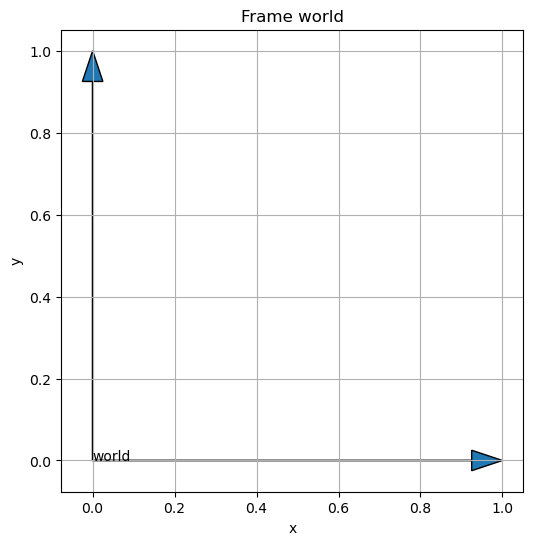

In [9]:
# Visualiza el frame world en el origen (0,0)
T_world = np.eye(3)
ax = plot_frame_2d(T_world, name='world', scale=1.0)
finalize_axes(ax, title='Frame world')

## Cambio de frame y composición (reglas prácticas)
- Si conocemos $\,T_{W}^{T}$ (de `turtle` a `world`) y $\,\bar{\mathbf{p}}_T$, entonces $\,\bar{\mathbf{p}}_W = T_{W}^{T}\,\bar{\mathbf{p}}_T$.
- Para invertir: $\,\bar{\mathbf{p}}_T = \left(T_{W}^{T}\right)^{-1} \bar{\mathbf{p}}_W$.
- Para encadenar frames: si $\,T_{W}^{A}$ y $\,T_{A}^{B}$ están dados, $\,T_{W}^{B} = T_{W}^{A} T_{A}^{B}$.
- En ROS (`tf2`), cada arista del grafo TF es una de estas transformaciones.


## 4) Ejemplo numérico: `turtle` → `world` y `world` → `turtle`
Supongamos que la tortuga está en $x=2.0$, $y=3.0$, y $\theta=45^\circ$ (yaw). Construimos la matriz $T_{\text{world}}^{\text{turtle}}$ y transformamos:
- Un punto delante de la tortuga: $\mathbf{p}_{\text{turtle}} = [1, 0, 1]^\top$.
- Luego invertimos la transformación para volver a `turtle`.


In [10]:
import numpy as np

def T2_from_xytheta(x: float, y: float, theta_deg: float) -> np.ndarray:
    """Crea la matriz homogénea 2D (3x3) para (x, y, theta_deg)."""
    th = np.deg2rad(theta_deg)
    c, s = np.cos(th), np.sin(th)
    T = np.array([[c, -s, x],
                  [s,  c, y],
                  [0,  0, 1]], dtype=float)
    return T

def transform_point(T: np.ndarray, p: np.ndarray) -> np.ndarray:
    """Transforma punto homogéneo p (3,) con matriz T (3x3)."""
    return T @ p

# Pose de la tortuga
x, y, theta_deg = 2.0, 3.0, 45.0
T_world_from_turtle = T2_from_xytheta(x, y, theta_deg)

# Punto en coordenadas de la tortuga (u, v, 1)
p_turtle = np.array([1.0, 0.0, 1.0])
# ACCIÓN FÍSICA: Aquí estamos preguntando: Si la tortuga ve un objeto 1 metro adelante de ella,
# ¿en qué coordenada exacta del mapa global (world) se encuentra ese objeto?
p_world = transform_point(T_world_from_turtle, p_turtle)

# Inversa para volver de world a turtle
T_turtle_from_world = np.linalg.inv(T_world_from_turtle)
p_back = transform_point(T_turtle_from_world, p_world)

T_world_from_turtle, p_world, p_back

(array([[ 0.70710678, -0.70710678,  2.        ],
        [ 0.70710678,  0.70710678,  3.        ],
        [ 0.        ,  0.        ,  1.        ]]),
 array([2.70710678, 3.70710678, 1.        ]),
 array([1., 0., 1.]))

El vector `p_back` debería recuperar (numéricamente) el punto original en el frame de la tortuga.

## 5) Visualización 2D (opcional)
Graficaremos los ejes del mundo y el frame de la tortuga con su orientación, además del punto transformado.


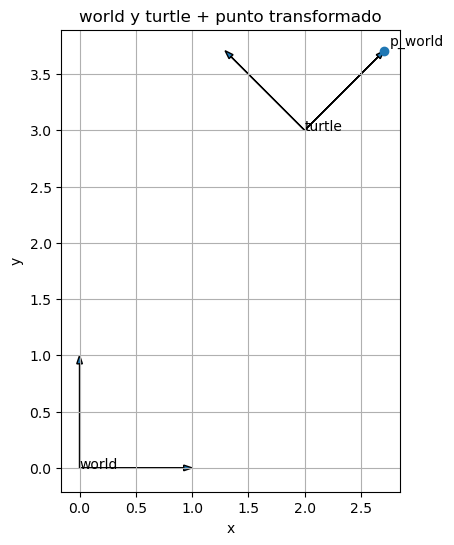

In [11]:
# Visualización: frame world + frame turtle y un punto transformado
x, y, theta_deg = 2.0, 3.0, 45.0
T_world_from_turtle = T2_from_xytheta(x, y, theta_deg)

# Punto en coordenadas de la tortuga
p_turtle = np.array([1.0, 0.0, 1.0])
p_world = T_world_from_turtle @ p_turtle

ax = plot_frame_2d(np.eye(3), name='world', scale=1.0)
ax = plot_frame_2d(T_world_from_turtle, name='turtle', axis=ax, scale=1.0)
ax = plot_point_2d(p_world, label='p_world', axis=ax)
finalize_axes(ax, title='world y turtle + punto transformado')

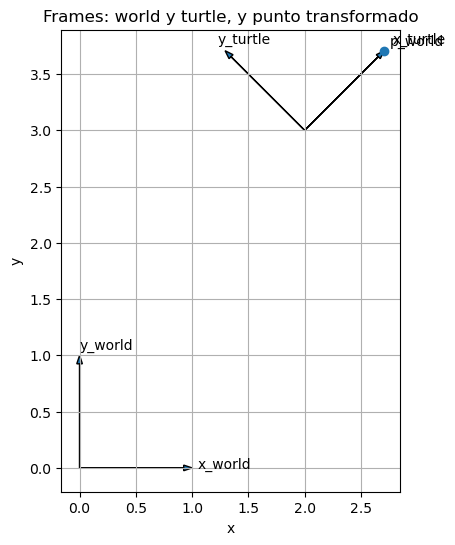

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frames_and_point(T_world_from_turtle: np.ndarray, p_world: np.ndarray):
    fig, ax = plt.subplots(figsize=(6,6))

    # Ejes del mundo
    ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True)
    ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True)
    ax.text(1.05, 0, 'x_world')
    ax.text(0, 1.05, 'y_world')

    # Ejes de la tortuga (transformados al mundo)
    # Origen de turtle en world
    ox, oy = T_world_from_turtle[0,2], T_world_from_turtle[1,2]
    # Dirección x_turtle y y_turtle en world (columnas de rotación)
    x_dir = T_world_from_turtle[:2,0]  # (cos, sin)
    y_dir = T_world_from_turtle[:2,1]  # (-sin, cos)
    ax.arrow(ox, oy, x_dir[0], x_dir[1], head_width=0.05, length_includes_head=True)
    ax.arrow(ox, oy, y_dir[0], y_dir[1], head_width=0.05, length_includes_head=True)
    ax.text(ox + x_dir[0]*1.1, oy + x_dir[1]*1.1, 'x_turtle')
    ax.text(ox + y_dir[0]*1.1, oy + y_dir[1]*1.1, 'y_turtle')

    # Punto transformado en world
    ax.plot(p_world[0], p_world[1], marker='o')
    ax.text(p_world[0] + 0.05, p_world[1] + 0.05, 'p_world')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.set_title('Frames: world y turtle, y punto transformado')
    plt.show()

plot_frames_and_point(T_world_from_turtle, p_world)

In [13]:
# Plantilla mínima de broadcaster con tf2_ros (Python) — SOLO REFERENCIA (no se ejecuta aquí)
# NOTA: Toda la matemática de senos, cosenos y matrices que vimos arriba es exactamente lo que 
# ROS 2 hace de fondo. Aquí convertimos el ángulo theta a un Cuaternión (qz, qw) para que ROS 2 lo entienda.
code = r'''
from rclpy.node import Node
from geometry_msgs.msg import TransformStamped
from tf2_ros import TransformBroadcaster

class TurtleTFBroadcaster(Node):
    def __init__(self):
        super().__init__('turtle_tf_broadcaster')
        self.br = TransformBroadcaster(self)
        # Suscribirse a /turtle1/pose y llamar a self.handle_pose(msg)

    def handle_pose(self, msg):
        t = TransformStamped()
        t.header.stamp = self.get_clock().now().to_msg()
        t.header.frame_id = 'world'    # frame padre
        t.child_frame_id = 'turtle1'   # frame hijo
        t.transform.translation.x = float(msg.x)
        t.transform.translation.y = float(msg.y)
        t.transform.translation.z = 0.0
        # Convertir yaw=msg.theta a cuaternión
        import math
        qz = math.sin(msg.theta/2.0)
        qw = math.cos(msg.theta/2.0)
        t.transform.rotation.x = 0.0
        t.transform.rotation.y = 0.0
        t.transform.rotation.z = qz
        t.transform.rotation.w = qw
        self.br.sendTransform(t)
'''
print(code)


from rclpy.node import Node
from geometry_msgs.msg import TransformStamped
from tf2_ros import TransformBroadcaster

class TurtleTFBroadcaster(Node):
    def __init__(self):
        super().__init__('turtle_tf_broadcaster')
        self.br = TransformBroadcaster(self)
        # Suscribirse a /turtle1/pose y llamar a self.handle_pose(msg)

    def handle_pose(self, msg):
        t = TransformStamped()
        t.header.stamp = self.get_clock().now().to_msg()
        t.header.frame_id = 'world'    # frame padre
        t.child_frame_id = 'turtle1'   # frame hijo
        t.transform.translation.x = float(msg.x)
        t.transform.translation.y = float(msg.y)
        t.transform.translation.z = 0.0
        # Convertir yaw=msg.theta a cuaternión
        import math
        qz = math.sin(msg.theta/2.0)
        qw = math.cos(msg.theta/2.0)
        t.transform.rotation.x = 0.0
        t.transform.rotation.y = 0.0
        t.transform.rotation.z = qz
        t.transform.rotation.w = qw
        

## 6) Ejemplo con dos tortugas y composición de transformaciones
Consideremos dos tortugas, `turtle1` y `turtle2`.
Supongamos que conocemos $T_{W}^{T1}$ y $T_{W}^{T2}$. Entonces, la transformación de `turtle1` a `turtle2` es:
$$T_{T1}^{T2} = \left(T_{W}^{T1}\right)^{-1} \, T_{W}^{T2}.$$
Análogamente, podemos obtener $\,T_{W}^{T2} = T_{W}^{T1} \, T_{T1}^{T2}$ si conocemos la relativa y la de `turtle1`.

A continuación, un ejemplo numérico y su visualización.

In [14]:
import numpy as np

# Poses en world
T_W_T1 = T2_from_xytheta(2.0, 3.0, 45.0)   # turtle1
T_W_T2 = T2_from_xytheta(4.0, 1.0, -20.0)  # turtle2

# Transformación relativa de T1 a T2
T_T1_T2 = np.linalg.inv(T_W_T1) @ T_W_T2

# Verificación: recomponer T_W_T2
T_W_T2_check = T_W_T1 @ T_T1_T2

# Transformar un punto expresado en turtle2 al frame world y luego a turtle1
p_T2 = np.array([1.0, 0.0, 1.0])
p_W = T_W_T2 @ p_T2
p_T1 = np.linalg.inv(T_W_T1) @ p_W

T_W_T1, T_W_T2, T_T1_T2, T_W_T2_check, p_W, p_T1

(array([[ 0.70710678, -0.70710678,  2.        ],
        [ 0.70710678,  0.70710678,  3.        ],
        [ 0.        ,  0.        ,  1.        ]]),
 array([[ 0.93969262,  0.34202014,  4.        ],
        [-0.34202014,  0.93969262,  1.        ],
        [ 0.        ,  0.        ,  1.        ]]),
 array([[ 0.42261826,  0.90630779,  0.        ],
        [-0.90630779,  0.42261826, -2.82842712],
        [ 0.        ,  0.        ,  1.        ]]),
 array([[ 0.93969262,  0.34202014,  4.        ],
        [-0.34202014,  0.93969262,  1.        ],
        [ 0.        ,  0.        ,  1.        ]]),
 array([4.93969262, 0.65797986, 1.        ]),
 array([ 0.42261826, -3.73473491,  1.        ]))

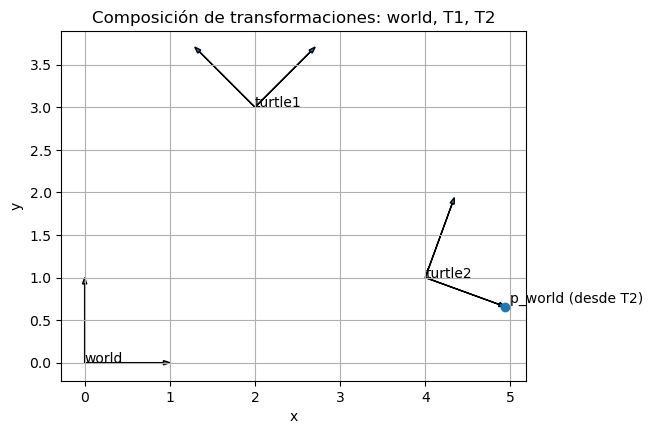

In [15]:
# Visualización de world, turtle1, turtle2 y el punto p_W
ax = plot_frame_2d(np.eye(3), name='world', scale=1.0)
ax = plot_frame_2d(T_W_T1, name='turtle1', axis=ax, scale=1.0)
ax = plot_frame_2d(T_W_T2, name='turtle2', axis=ax, scale=1.0)
ax = plot_point_2d(p_W, label='p_world (desde T2)', axis=ax)
finalize_axes(ax, title='Composición de transformaciones: world, T1, T2')

### Nota
- En ROS 2, para publicar esta transformación en vivo usarías un **broadcaster** (`tf2_ros`) que convierta la pose de la tortuga `/turtle1/pose` en un `TransformStamped` con `frame_id='world'` y `child_frame_id='turtle1'`.
- En RViz, seleccionas `Fixed Frame = world`, activas las visualizaciones de **TF** y **RobotModel** (si publicas un URDF con `robot_state_publisher`).


## ¿Cómo se especifica qué frame es *parent* y cuál es *child* en ROS 2?

### 1. En un mensaje `TransformStamped`
Cada transformación publicada en `tf2` es un mensaje con dos campos clave:
- `header.frame_id`: el **frame padre**.
- `child_frame_id`: el **frame hijo**.

Ejemplo en Python:
```python
t = TransformStamped()
t.header.stamp = self.get_clock().now().to_msg()
t.header.frame_id = 'world'      # parent frame
t.child_frame_id = 'turtle1'     # child frame
```
Esto define la relación **`world → turtle1`**.

### 2. En un URDF con `robot_state_publisher`
Los *joints* definen padres e hijos en el archivo URDF:
```xml
<joint name="camera_joint" type="fixed">
  <parent link="base_link"/>
  <child link="camera_link"/>
  <origin xyz="0 0 1.0" rpy="0 0 0"/>
</joint>
```
Aquí se establece la relación **`base_link → camera_link`**.

### 3. Construcción del grafo TF
Cada arista del grafo TF se construye a partir de estas relaciones. En RViz, la visualización de TF muestra esta jerarquía.

Ejemplo de árbol TF (ASCII):
```text
world
 └── base_link
      └── camera_link
           └── optical_frame
```

### Resumen
- En `tf2`: usas `header.frame_id` y `child_frame_id`.
- En URDF: usas `<parent>` y `<child>` en los `joint`.
- ROS 2 arma automáticamente el grafo de transformaciones y permite consultas entre cualquier par de frames.


## Conclusión: ¿Por qué ROS 2 usa `tf2`?
- En robótica, los cálculos de $SE(3)$ (transformaciones homogéneas) son continuos y se actualizan a lo largo del tiempo.
- Hacer manualmente todas las multiplicaciones de matrices e interpolaciones temporales es complejo y propenso a errores.

**`tf2` en ROS 2 resuelve esto automáticamente:**
- Mantiene un **grafo de transformaciones** (árbol TF) donde cada nodo publica sus frames relativos (ej. `base_link → camera_link`).
- Gestiona la **interpolación temporal**: permite consultar la transformación válida en el instante exacto de un mensaje de sensor.
- Se integra con **RViz2** para visualizar el árbol TF y con paquetes como `robot_state_publisher` para difundir URDFs.

### Uso de `tf2`
- **Broadcaster**: publicas `TransformStamped` (traslación + rotación) entre frames.
- **Listener**: consultas transformaciones entre dos frames en un tiempo $t$.
- Ejemplo: convertir la nube de puntos de una cámara (`camera_link`) al frame del mapa global (`map`) usando $T_{map}^{camera}$ provisto por `tf2`.

En resumen: **`tf2` es el motor matemático de ROS 2 para manejar todos los $SO(3)$ y $SE(3)$ de manera transparente y en tiempo real.**


---
# Anexo Matemático: Para profundizar
Las siguientes secciones detallan el formalismo matemático riguroso detrás de las transformaciones que ROS 2 ejecuta por nosotros.


## Conceptos previos: Grupos $SO(n)$ y $SE(n)$
- $SO(n)$: **Special Orthogonal group** en dimensión $n$. Contiene todas las matrices de rotación $R\in\mathbb{R}^{n\times n}$ que cumplen:
$$R^\top R = I, \quad \det(R) = 1.$$
En 2D ($SO(2)$) son rotaciones en el plano, y en 3D ($SO(3)$) son rotaciones en el espacio.

- $SE(n)$: **Special Euclidean group** en dimensión $n$. Es el conjunto de **transformaciones rígidas** (rotación + traslación), que se escriben como matrices homogéneas:
$$T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}, \quad R\in SO(n),\; \mathbf{t}\in\mathbb{R}^n.$$
En 2D hablamos de $SE(2)$ y en 3D de $SE(3)$.

Estos grupos describen la cinemática de robots y frames de referencia.


## Fundamentos matemáticos (2D/3D) — Notación y convenciones
- Un **frame** (sistema de referencia) se denota con una letra: $\,\{W\}$ (world), $\,\{T\}$ (turtle).
- Un **punto** expresado en el frame $\{T\}$ se escribe $\,\mathbf{p}_T\in\mathbb{R}^2$ (2D) o $\,\mathbb{R}^3$ (3D).
- La **rotación** de $\{T\}$ respecto a $\{W\}$ se denota con $\,R\in\mathrm{SO}(2)$ en 2D y $\,R\in\mathrm{SO}(3)$ en 3D.
- La **traslación** del origen de $\{T\}$ en coordenadas de $\{W\}$ es $\,\mathbf{t}\in\mathbb{R}^2$ (2D) o $\,\mathbb{R}^3$ (3D).

### Homogeneización
Definimos la coordenada homogénea de un punto 2D como $\,\bar{\mathbf{p}}=[x\;y\;1]^\top\,$ y en 3D como $\,\bar{\mathbf{p}}=[x\;y\;z\;1]^\top$.


## Grupo de transformaciones rígidas en 2D: $\mathrm{SE}(2)$
Una transformación rígida 2D se expresa como:
$$T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix},\quad R\in\mathrm{SO}(2),\; \mathbf{t}\in\mathbb{R}^2,$$
donde la matriz de rotación es:
$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}.$$
Aplicación a un punto (convención pasiva / cambio de base):
$$\bar{\mathbf{p}}_W = T_{W}^{T}\,\bar{\mathbf{p}}_T,$$
lo cual, en coordenadas cartesianas, equivale a:
$$\mathbf{p}_W = R\,\mathbf{p}_T + \mathbf{t}.$$

### Inversa y composición en $\mathrm{SE}(2)$
La **inversa** de $\,T$ es:
$$T^{-1} = \begin{bmatrix} R^\top & -R^\top\,\mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}.$$
La **composición** de dos transformaciones $\,T_{W}^{A}$ y $\,T_{A}^{B}$ es:
$$T_{W}^{B} = T_{W}^{A}\,T_{A}^{B}.$$


## Caso 2D (turtlesim) — Forma explícita
Para la tortuga con pose $\,(x, y, \theta)\,$ en `world`, la transformación es:
$$T_{W}^{T} = \begin{bmatrix} \cos\theta & -\sin\theta & x \\ \sin\theta & \cos\theta & y \\ 0 & 0 & 1 \end{bmatrix}.$$
Transformación de un punto $\,\mathbf{p}_T=[u\;v]^\top$ expresado en el frame de la tortuga:
$$\mathbf{p}_W = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} u \\ v \end{bmatrix} + \begin{bmatrix} x \\ y \end{bmatrix}.$$
Si usamos coordenadas homogéneas $\,\bar{\mathbf{p}}=[u\;v\;1]^\top$:
$$\bar{\mathbf{p}}_W = T_{W}^{T}\,\bar{\mathbf{p}}_T.$$
La inversa explícita (útil para `world` $\to$ `turtle`) es:
$$\left(T_{W}^{T}\right)^{-1} = \begin{bmatrix} \cos\theta & \sin\theta & -x\,\cos\theta - y\,\sin\theta \\ -\sin\theta & \cos\theta & x\,\sin\theta - y\,\cos\theta \\ 0 & 0 & 1 \end{bmatrix}.$$


## Grupo de transformaciones rígidas en 3D: $\mathrm{SE}(3)$ (referencia)
En 3D se usa:
$$T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix},\quad R\in\mathrm{SO}(3),\; \mathbf{t}\in\mathbb{R}^3,$$
con $\,R$ ortonormal: $\,R^\top R = I,\;\det(R)=1$.
Aplicación a un punto:
$$\mathbf{p}_W = R\,\mathbf{p}_T + \mathbf{t},\qquad \bar{\mathbf{p}}_W = T\,\bar{\mathbf{p}}_T.$$
La inversa:
$$T^{-1} = \begin{bmatrix} R^\top & -R^\top\,\mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}.$$

### Rotaciones en 3D
Con ángulos de Euler ZYX ($\psi,\theta,\phi$):
$$R = R_z(\psi)\,R_y(\theta)\,R_x(\phi).$$
Con cuaterniones unitarios $\,q = (q_x, q_y, q_z, q_w)$, la matriz $R(q)$ (forma estándar) es:
$$R(q)=\begin{bmatrix}
1-2(q_y^2+q_z^2) & 2(q_x q_y - q_z q_w) & 2(q_x q_z + q_y q_w) \\
2(q_x q_y + q_z q_w) & 1-2(q_x^2+q_z^2) & 2(q_y q_z - q_x q_w) \\
2(q_x q_z - q_y q_w) & 2(q_y q_z + q_x q_w) & 1-2(q_x^2+q_y^2)
\end{bmatrix}.$$


## 3) Transformación homogénea en 3D (general)
En 3D, la forma general es:

$$
T = \begin{bmatrix}
R_{3\times 3} & \mathbf{t}_{3\times 1} \\
0\;0\;0 & 1
\end{bmatrix}
$$

donde $R$ es la matriz de rotación y $\mathbf{t} = [x\;y\;z]^\top$ es la traslación.
Con ángulos de Euler ZYX (yaw–pitch–roll), $R = R_z(\psi)\,R_y(\theta)\,R_x(\phi)$.
